In [2]:
import json
import warnings
import numpy as np
import xarray as xr
import proplot as pplt
warnings.filterwarnings('ignore')
pplt.rc.update({'figure.dpi':100})

In [9]:
with open('../scripts/configs.json','r',encoding='utf-8') as f:
    CONFIGS = json.load(f)
INTERIMDIR = CONFIGS['filepaths']['interim']
LATRANGE   = CONFIGS['domain']['latrange']
LONRANGE   = CONFIGS['domain']['lonrange']

In [21]:
PROFILEVARS = {
    't':{'label':'$\\mathit{T}$','units':'K'},
    'q':{'label':'$\\mathit{q}$','units':'kg/kg'},
    'rh':{'label':'RH','units':'%'},
    'thetae':{'label':'$\\mathit{\\theta_{e}}$','units':'K'},
    'thetaestar':{'label':'$\\mathit{\\theta_{e}^*}$','units':'K'}}

sigma = {}
pressure = {}
for varname in PROFILE_VARS:
    sigma[varname]    = xr.open_dataarray(f'{INTERIMDIR}/{varname}.nc',engine='h5netcdf')
    pressure[varname] = xr.open_dataarray(f'{INTERIMDIR}/deprecated/{varname}.nc',engine='h5netcdf')

ps = xr.open_dataarray(f'{INTERIMDIR}/ps.nc',engine='h5netcdf')
print(f'Sigma variables have dims:    {list(sigma["t"].dims)}')
print(f'Pressure variables have dims: {list(pressure["t"].dims)}')

Sigma variables have dims:    ['lat', 'lon', 'sig', 'time']
Pressure variables have dims: ['lat', 'lon', 'lev', 'time']


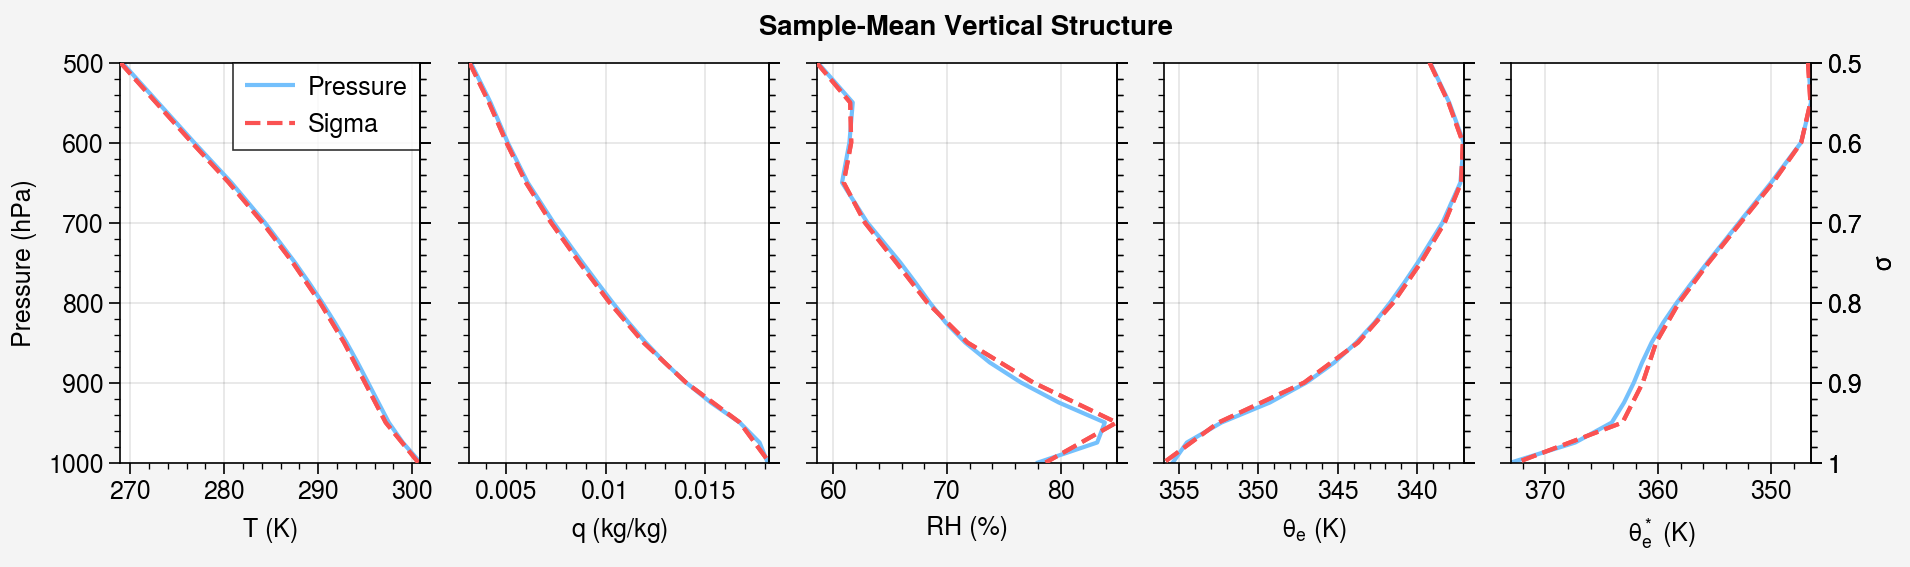

In [53]:
fig,axs = pplt.subplots(nrows=1,ncols=len(PROFILE_VARS),refwidth=1.5,refheight=2,sharex=False,sharey=True)
axs.format(suptitle='Sample-Mean Vertical Structure',ylabel='Pressure (hPa)',yreverse=True,ylim=(1000,500))
bxs = []
for i,(varname,info) in enumerate(PROFILE_VARS.items()):
    pressureda = pressure[varname].mean(dim=('lat','lon','time')).load()
    sigmada    = sigma[varname].mean(dim=('lat','lon','time')).load()
    plevs = pressureda.lev.values
    slevs = sigmada.sig.values
    bx = axs[i].twinx()
    bxs.append(bx)
    axs[i].plot(pressureda.values,plevs,color='blue3',linewidth=1.5,label='Pressure')
    bx.plot(sigmada.values,slevs,color='red6',linewidth=1.5,linestyle='--',label='Sigma')
    axs[i].format(xlabel=f'{info["label"]} ({info["units"]})')
    bx.format(yreverse=True,ylim=(1.0,0.5),yticklabels='none')

bxs[-1].format(ylabel='$\\sigma$',yticklabels='auto')
lines1,labels1 = axs[0].get_legend_handles_labels()
lines2,labels2 = bxs[0].get_legend_handles_labels()
axs[0].legend(lines1+lines2,labels1+labels2,loc='ur',ncols=1)
pplt.show()

In [ ]:
# Interpolation smoothing: fractional change in vertical std
lf = xr.open_dataarray(f'{INTERIMDIR}/lf.nc',engine='h5netcdf').load()

fig,axs = pplt.subplots(nrows=1,ncols=len(PROFILE_VARS),proj='cyl',refwidth=2.5,refheight=2)
axs.format(suptitle='Fractional change in vertical std: ($\\sigma_{\\sigma}$ - $\\sigma_{p}$) / $\\sigma_{p}$',
           coast=True,grid=False,latlim=LATRANGE,lonlim=LONRANGE)

frac_changes = {}
for i,(varname,info) in enumerate(PROFILE_VARS.items()):
    pstd = pressure[varname].std(dim='lev').mean(dim='time').load()
    sstd = sigma[varname].std(dim='sig').mean(dim='time').load()
    frac = ((sstd - pstd) / pstd).where(pstd > 0)
    frac_changes[varname] = frac
    im = axs[i].pcolormesh(frac.lon,frac.lat,frac,cmap='ColdHot',vmin=-0.3,vmax=0.3,levels=21,extend='both')
    axs[i].format(title=info['label'])

fig.colorbar(im,loc='r',label='Fractional change')
pplt.show()

In [ ]:
# Smoothing vs surface pressure
psmean = ps.mean(dim='time').load()

fig,axs = pplt.subplots(nrows=1,ncols=len(PROFILE_VARS),refwidth=2,refheight=2.5,sharex=True,sharey=True)
axs.format(suptitle='Interpolation smoothing vs surface pressure',
           xlabel='Time-mean $p_s$ (hPa)',ylabel='Fractional change in vertical std')

for i,(varname,info) in enumerate(PROFILE_VARS.items()):
    frac   = frac_changes[varname]
    psflat = psmean.values.ravel()
    fracflat = frac.values.ravel()
    lfflat = lf.values.ravel()
    valid  = np.isfinite(psflat) & np.isfinite(fracflat)
    axs[i].scatter(psflat[valid],fracflat[valid],c=lfflat[valid],s=15,cmap='BuGn',vmin=0,vmax=1,
                   edgecolors='none',alpha=0.7)
    axs[i].axhline(0,color='k',linewidth=0.8,linestyle='--')
    axs[i].format(title=info['label'],xlim=(700,1025))

fig.colorbar(axs[0].collections[0],loc='r',label='Land fraction')
pplt.show()

In [ ]:
# Extrapolation frequency by sigma level
# A sigma level requires extrapolation when sig < 500 / ps (top of ERA5 data domain)
PTOP = 500.0
siglevels = np.arange(0.5,1.05,0.05)
show_sigs = [0.5,0.55,0.6,0.65]

fig,axs = pplt.subplots(nrows=1,ncols=len(show_sigs),proj='cyl',refwidth=2.5,refheight=2)
axs.format(suptitle='Fraction of timesteps requiring extrapolation',
           coast=True,grid=False,latlim=LATRANGE,lonlim=LONRANGE)

for i,siglev in enumerate(show_sigs):
    sig_top = PTOP / ps
    extrap_frac = (siglev < sig_top).astype(float).mean(dim='time').load()
    im = axs[i].pcolormesh(extrap_frac.lon,extrap_frac.lat,extrap_frac,
                           cmap='Fire',vmin=0,vmax=1,levels=11,extend='neither')
    axs[i].format(title=f'$\\sigma$ = {siglev:.2f}')

fig.colorbar(im,loc='r',label='Extrapolation frequency')
pplt.show()